# Theme recovery (held-out gold labels)

Stratified **70 / 15 / 15** on gold `dimension`. The agent is run on **train** only; use `evaluation/train.csv` (same row order as `codes_per_review` review ids 1…*n*). Splits add `text_review` for `agents.cli --data`.

Data, split CSVs, and copied pipeline JSONs live in **`evaluation/`** next to this notebook. Embedding weights stay under **`agents/weights/`** at the repo root.

**Val/test:** `sentence-transformers` embeddings; **sklearn `NearestCentroid`** (cosine) assigns the same *discovered* theme labels as on train.

**Evaluation:** majority vote on **validation** maps discovered → gold; fixed mapping on **test**. Metrics from **sklearn**.


In [1]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestCentroid

REPO = Path.cwd().resolve()
if not (REPO / "agents").is_dir():
    REPO = REPO.parent

EVAL_DIR = REPO / "evaluation"
SRC_CSV = EVAL_DIR / "school_burnout_synthetic.csv"
ARTIFACTS = EVAL_DIR
EMBED_WEIGHTS = REPO / "agents" / "weights" / "Qwen3-Embedding-0.6B"

RANDOM_STATE = 42
GOLD_COL = "dimension"
TEXT_COL = "text"
SENTINEL = "__no_codes__"


## 1. Stratified split and CSV export

In [3]:
df = pd.read_csv(SRC_CSV)

idx = np.arange(len(df))
y = df[GOLD_COL].astype(str)

idx_train, idx_temp, _, y_temp = train_test_split(
    idx, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)
test_df = df.iloc[idx_test].reset_index(drop=True)

for d, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    out = d.copy()
    out["text_review"] = out[TEXT_COL].astype(str)
    out.to_csv(EVAL_DIR / f"{name}.csv", index=False)
    print(name, len(out), "->", EVAL_DIR / f"{name}.csv")

with open(EVAL_DIR / "split_indices.json", "w", encoding="utf-8") as f:
    json.dump(
        {"random_state": RANDOM_STATE, "train": idx_train.tolist(), "val": idx_val.tolist(), "test": idx_test.tolist()},
        f,
        indent=2,
    )


train 315 -> /scratch/nimamot/evaluation/train.csv
val 67 -> /scratch/nimamot/evaluation/val.csv
test 68 -> /scratch/nimamot/evaluation/test.csv


## 2. Train discovered theme from pipeline artifacts

Copy `gt_clustered_codes.json`, `codebook.json`, and (if needed) `gt_codes_only.json` into **`evaluation/`** after a train-only pipeline run with `--data` pointing at **`evaluation/train.csv`**.


In [4]:
with open(ARTIFACTS / "gt_clustered_codes.json", encoding="utf-8") as f:
    clustered = json.load(f)
with open(ARTIFACTS / "codebook.json", encoding="utf-8") as f:
    codebook = json.load(f).get("codebook", {})

cluster_to_codes = clustered["cluster_to_codes"]
code_to_cid = {}
for cid, codes in cluster_to_codes.items():
    for c in codes:
        code_to_cid[str(c)] = str(cid)

cpr = clustered.get("codes_per_review")
if not cpr:
    with open(ARTIFACTS / "gt_codes_only.json", encoding="utf-8") as f:
        cpr = json.load(f)["codes_per_review"]

by_rid = {int(a): [str(c) for c in b] for a, b in cpr}
n_train = len(train_df)

def dominant_cid(codes):
    cids = [code_to_cid[c] for c in codes if c in code_to_cid]
    if not cids:
        return None
    cnt = Counter(cids)
    best = max(cnt.values())
    return sorted([k for k, v in cnt.items() if v == best], key=int)[0]

discovered, cids = [], []
for i in range(1, n_train + 1):
    cid = dominant_cid(by_rid.get(i, []))
    cids.append(cid)
    discovered.append(codebook.get(str(cid), f"Cluster {cid}") if cid else SENTINEL)

train_df = train_df.assign(discovered_theme=discovered, dominant_cluster_id=cids)
display(train_df[[GOLD_COL, "discovered_theme"]].head(10))


,dimension,discovered_theme
0,Sense of inadequacy at school,Academic distress and burnout
1,Sense of inadequacy at school,Motivational and emotional decline
2,Cynicism toward the meaning of school,Emotional disconnection and burden
3,Sense of inadequacy at school,Academic distress and burnout
4,Exhaustion at school,Chronic academic burnout
5,Exhaustion at school,emotional and cognitive overload
6,Exhaustion at school,Chronic academic burnout
7,Exhaustion at school,Motivational and emotional decline
8,Exhaustion at school,Chronic academic burnout
9,Exhaustion at school,Chronic academic burnout


## 3. Embeddings and nearest-centroid prediction on val/test

`pip install sentence_transformers` if needed. Set `GT_EMBED_MODEL` or keep Qwen3-Embedding weights under the repo’s `agents/weights/` (see first code cell).


In [6]:
import os
from sentence_transformers import SentenceTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

model_name = os.environ.get("GT_EMBED_MODEL") or (
    str(EMBED_WEIGHTS.resolve()) if EMBED_WEIGHTS.is_dir() else "Qwen/Qwen3-Embedding-0.6B"
)
embedder = SentenceTransformer(model_name, device="cpu")

def encode(texts):
    return np.asarray(
        embedder.encode(texts, normalize_embeddings=True, batch_size=32, show_progress_bar=True),
        dtype=np.float32,
    )

E_train = encode(train_df[TEXT_COL].astype(str).tolist())
E_val = encode(val_df[TEXT_COL].astype(str).tolist())
E_test = encode(test_df[TEXT_COL].astype(str).tolist())

ok = train_df["discovered_theme"] != SENTINEL
clf =  make_pipeline(Normalizer(norm="l2"), NearestCentroid(metric="euclidean"))
clf.fit(E_train[ok.to_numpy()], train_df.loc[ok, "discovered_theme"])

val_df = val_df.assign(discovered_theme=clf.predict(E_val))
test_df = test_df.assign(discovered_theme=clf.predict(E_test))
display(val_df[[GOLD_COL, "discovered_theme"]].head())


Batches: 100%|██████████| 3/3 [00:11<00:00,  3.96s/it]


,dimension,discovered_theme
0,Exhaustion at school,Emotional disconnection and burden
1,Exhaustion at school,Motivational and emotional decline
2,Exhaustion at school,emotional and cognitive overload
3,Sense of inadequacy at school,Motivational and emotional decline
4,Cynicism toward the meaning of school,Pedagogical disengagement


## 4. Validation mapping and test metrics (sklearn)

In [9]:
UNMAPPED = "__UNMAPPED_PRED__"
gold_labels = sorted(df[GOLD_COL].astype(str).unique())

mapping = {}
for d in val_df["discovered_theme"].unique():
    sub = val_df.loc[val_df["discovered_theme"] == d, GOLD_COL]
    mapping[d] = Counter(sub).most_common(1)[0][0]

print("discovered → gold (from validation)")
for k in sorted(mapping):
    print(f"  {k!r} → {mapping[k]!r}")


def to_gold(series):
    return [mapping.get(x, UNMAPPED) for x in series]


y_val_true = val_df[GOLD_COL].astype(str)
y_test_true = test_df[GOLD_COL].astype(str)
y_val_pred = to_gold(val_df["discovered_theme"])
y_test_pred = to_gold(test_df["discovered_theme"])



print("\ntest")
print("accuracy", accuracy_score(y_test_true, y_test_pred))
print(
    "macro F1",
    f1_score(y_test_true, y_test_pred, average="macro", labels=gold_labels, zero_division=0),
)
print("\n", classification_report(y_test_true, y_test_pred, zero_division=0))

lab = sorted(set(y_test_true) | set(y_test_pred))
cm = confusion_matrix(y_test_true, y_test_pred, labels=lab)
display(pd.DataFrame(cm, index=lab, columns=lab))


discovered → gold (from validation)
  'Academic distress and burnout' → 'Sense of inadequacy at school'
  'Chronic academic burnout' → 'Exhaustion at school'
  'Emotional disconnection and burden' → 'Exhaustion at school'
  'Motivational and emotional decline' → 'Cynicism toward the meaning of school'
  'Pedagogical disengagement' → 'Cynicism toward the meaning of school'
  'emotional and cognitive overload' → 'Exhaustion at school'
  'epistemic disconnection' → 'Cynicism toward the meaning of school'

test
accuracy 0.8529411764705882
macro F1 0.8332171334695677

                                        precision    recall  f1-score   support

Cynicism toward the meaning of school       0.83      0.87      0.85        23
                 Exhaustion at school       0.93      0.90      0.92        30
        Sense of inadequacy at school       0.73      0.73      0.73        15

                             accuracy                           0.85        68
                            macr

,Cynicism toward the meaning of school,Exhaustion at school,Sense of inadequacy at school
Cynicism toward the meaning of school,20,1,2
Exhaustion at school,1,27,2
Sense of inadequacy at school,3,1,11


## 5. Test confusion matrix (matplotlib)

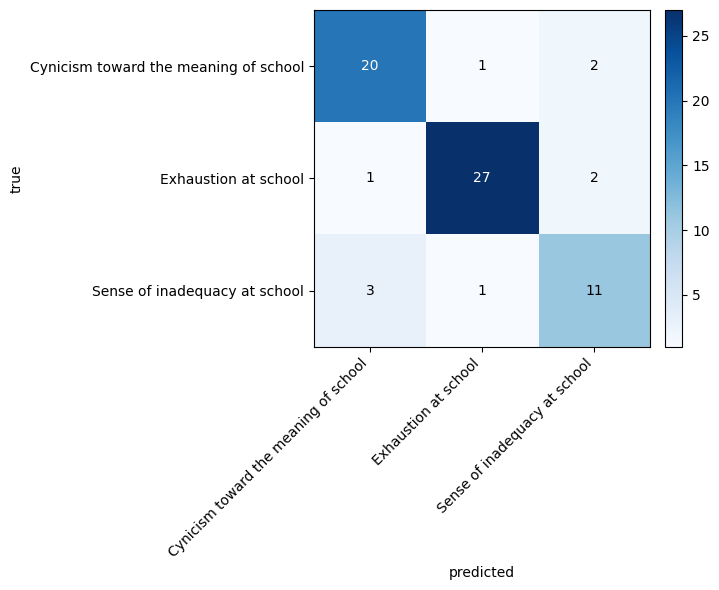

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(lab)), labels=lab, rotation=45, ha="right")
ax.set_yticks(range(len(lab)), labels=lab)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout()
plt.show()
